<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/11.testes_estatisticosipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Testes Estatísticos - Taxa de Internação em Saúde Mental**

**Objetivo**

Este notebook realiza a análise estatística da variável `taxa_internacao`.

**Autor:** Larissa Tinem


# **1. Instalação de pacotes**

O pacote `scikit-posthocs` será usado no pós-teste de Dunn.

In [ ]:
!pip install scikit-posthocs

# **2. Importação das bibliotecas e carregamento dos dados**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import geopandas as gpd
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_analitica = pd.read_parquet('/content/drive/MyDrive/Dados/base_analitica/base_analitica.parquet')

In [ ]:
# CONFERÊNCIA INICIAL DAS BASES
# Mostra quantidade de linhas e colunas da base
print('Dimensão da base:')
print(base_analitica.shape)

# Mostra nomes das colunas disponíveis
print('\nColunas da base:')
print(base_analitica.columns.tolist())

# Verifica valores ausentes nas principais variáveis
print('\nValores ausentes nas variáveis principais:')
print(
    base_analitica[
        ['cod_municipio', 'municipio', 'ano', 'drs', 'populacao', 'taxa_internacao', 'periodo_pandemia']
    ].isna().sum()
)

# Confere quantidade de registros por período
print('\nQuantidade de registros por período:')
print(base_analitica['periodo_pandemia'].value_counts())

Dimensão da base:
(64337, 16)

Colunas da base:
['cod_municipio', 'municipio', 'ano', 'mes', 'data_mes', 'cod_drs', 'drs', 'periodo_pandemia', 'populacao', 'n_internacoes', 'taxa_internacao', 'n_mortes', 'taxa_mortalidade', 'media_dias_perm', 'n_caps', 'caps_por_100k']

Valores ausentes nas variáveis principais:
cod_municipio       0
municipio           0
ano                 0
drs                 0
populacao           0
taxa_internacao     0
periodo_pandemia    0
dtype: int64

Quantidade de registros por período:
periodo_pandemia
pre         30799
pos         21136
pandemia    12402
Name: count, dtype: int64


# **3. Estatística Descritiva**

In [ ]:
# Calcula estatísticas gerais da taxa de internação
base_analitica['taxa_internacao'].describe()

,taxa_internacao
count,64337.000000
mean,34.034229
std,45.693128
min,0.339131
25%,11.341726
50%,21.665485
75%,40.702111
max,807.821178


In [ ]:
# Calcula mediana da taxa de internação por período
mediana_periodo = (
    base_analitica
    .groupby('periodo_pandemia')['taxa_internacao']
    .median()
    .sort_index()
)

# Exibe o resultado
mediana_periodo

,taxa_internacao
periodo_pandemia,
pandemia,18.556575
pos,23.252454
pre,21.958718


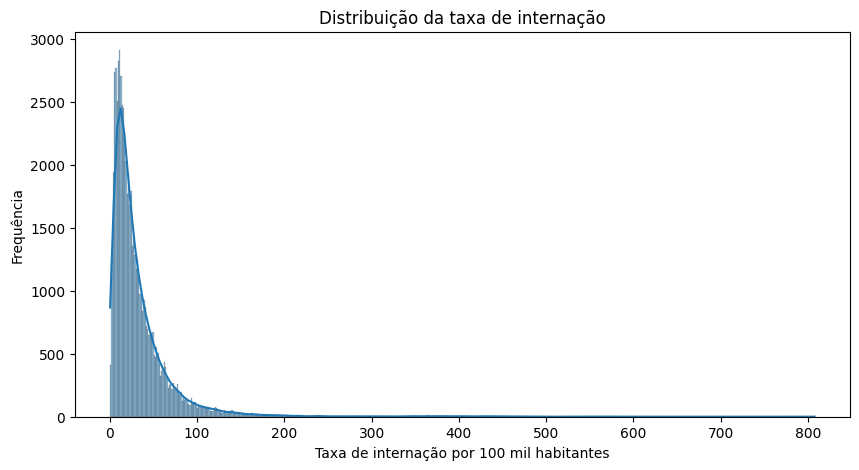

In [ ]:
# VISUALIZAÇÃO DA DISTRIBUIÇÃO

# Cria histograma da taxa de internação
plt.figure(figsize=(10, 5))
sns.histplot(base_analitica['taxa_internacao'], kde=True)

# Define título e rótulos do gráfico
plt.title('Distribuição da taxa de internação')
plt.xlabel('Taxa de internação por 100 mil habitantes')
plt.ylabel('Frequência')

# Exibe o gráfico
plt.show()

# **4. Teste de Normalidade - Shapiro-Wilk**

Critério:

- `p > 0,05`: distribuição aproximadamente normal;
- `p <= 0,05`: distribuição não normal.

In [ ]:
# Seleciona a variável que será testada
taxa = base_analitica['taxa_internacao'].dropna()

# Função para limitar a amostra do Shapiro-Wilk a 5000 observações
# Isso evita problemas quando a base é muito grande
def preparar_amostra_shapiro(serie, limite=5000):
    # Remove valores ausentes
    serie = serie.dropna()

    # Sorteia amostra se a série for muito grande
    if len(serie) > limite:
        return serie.sample(limite, random_state=42)

    # Retorna a série original se estiver dentro do limite
    return serie

# Prepara os dados para o teste
taxa_teste = preparar_amostra_shapiro(taxa)

# Aplica o teste de Shapiro-Wilk
stat, p_valor = stats.shapiro(taxa_teste)

# Exibe os resultados
print('Teste de Normalidade - Shapiro-Wilk')
print('N utilizado no teste:', len(taxa_teste))
print('Estatística:', stat)
print('p-valor:', p_valor)

# Interpreta o resultado
if p_valor > 0.05:
    print('Resultado: a taxa de internação apresenta distribuição aproximadamente normal.')
else:
    print('Resultado: a taxa de internação NÃO apresenta distribuição normal.')

Teste de Normalidade - Shapiro-Wilk
N utilizado no teste: 5000
Estatística: 0.5395203184398625
p-valor: 2.226196654688667e-78
Resultado: a taxa de internação NÃO apresenta distribuição normal.


In [ ]:
# TESTE DE NORMALIDADE POR PERÍODO

# Exibe título da análise
print('Teste de normalidade por período:')

# Percorre cada período da pandemia existente na base
for periodo in base_analitica['periodo_pandemia'].dropna().unique():

    # Filtra a taxa de internação apenas para o período atual
    dados_periodo = base_analitica.loc[
        base_analitica['periodo_pandemia'] == periodo,
        'taxa_internacao'
    ].dropna()

    # Prepara amostra para o Shapiro-Wilk
    dados_periodo_teste = preparar_amostra_shapiro(dados_periodo)

    # O Shapiro precisa de pelo menos 3 observações
    if len(dados_periodo_teste) >= 3:

        # Aplica o teste de normalidade
        stat, p_valor = stats.shapiro(dados_periodo_teste)

        # Exibe resultados do período
        print(f'Período: {periodo}')
        print(f'N utilizado no teste: {len(dados_periodo_teste)}')
        print(f'Estatística: {stat}')
        print(f'p-valor: {p_valor}')

        # Interpreta o resultado
        if p_valor > 0.05:
            print('Interpretação: distribuição aproximadamente normal.')
        else:
            print('Interpretação: distribuição NÃO normal.')

    else:
        # Mensagem caso o período tenha poucos dados
        print(f'Período: {periodo}')
        print('Poucos dados para aplicar o teste.')

Teste de normalidade por período:
Período: pre
N utilizado no teste: 5000
Estatística: 0.460335141707764
p-valor: 8.280413396105824e-82
Interpretação: distribuição NÃO normal.
Período: pandemia
N utilizado no teste: 5000
Estatística: 0.595711808126874
p-valor: 1.2712645279202083e-75
Interpretação: distribuição NÃO normal.
Período: pos
N utilizado no teste: 5000
Estatística: 0.6572869627235702
p-valor: 3.4003282376527113e-72
Interpretação: distribuição NÃO normal.


# **5. Comparação entre períodos - Kruskal-Wallis**

Como a taxa não apresentou normalidade, usamos um teste não paramétrico para comparar os três períodos.

Critério:

- `p <= 0,05`: existe diferença significativa entre pelo menos dois períodos;
- `p > 0,05`: não há diferença significativa entre os períodos.


In [ ]:
# Separa a taxa de internação de cada período
pre = base_analitica.loc[
    base_analitica['periodo_pandemia'] == 'pre',
    'taxa_internacao'
].dropna()

pandemia = base_analitica.loc[
    base_analitica['periodo_pandemia'] == 'pandemia',
    'taxa_internacao'
].dropna()

pos = base_analitica.loc[
    base_analitica['periodo_pandemia'] == 'pos',
    'taxa_internacao'
].dropna()

# Aplica o teste de Kruskal-Wallis
stat, p_valor = stats.kruskal(pre, pandemia, pos)

# Exibe os resultados
print('Teste de Kruskal-Wallis')
print('Estatística:', stat)
print('p-valor:', p_valor)

# Interpreta o resultado
if p_valor <= 0.05:
    print('Resultado: existe diferença estatisticamente significativa entre os períodos.')
else:
    print('Resultado: não foi encontrada diferença estatisticamente significativa entre os períodos.')

Teste de Kruskal-Wallis
Estatística: 446.8829717981938
p-valor: 9.132625432390699e-98
Resultado: existe diferença estatisticamente significativa entre os períodos.


# **6. Dunn Post-Test**

In [ ]:
import scikit_posthocs as sp
# Aplica o pós-teste de Dunn para comparar os períodos dois a dois
resultado_dunn = sp.posthoc_dunn(
    base_analitica,
    val_col='taxa_internacao',
    group_col='periodo_pandemia',
    p_adjust='bonferroni'
)

# Exibe a matriz de p-valores das comparações entre períodos
resultado_dunn

,pandemia,pos,pre
pandemia,1.000000e+00,2.969930e-91,1.204513e-71
pos,2.969930e-91,1.000000e+00,4.279807e-05
pre,1.204513e-71,4.279807e-05,1.000000e+00


# **7. Análise Final Por Período**

In [ ]:
# Calcula resumo da taxa de internação por período
resumo_periodo = (
    base_analitica
    .groupby('periodo_pandemia')
    .agg(
        n_observacoes=('taxa_internacao', 'count'),
        mediana_taxa=('taxa_internacao', 'median'),
        media_taxa=('taxa_internacao', 'mean'),
        desvio_padrao=('taxa_internacao', 'std'),
        minimo=('taxa_internacao', 'min'),
        maximo=('taxa_internacao', 'max')
    )
    .reset_index()
)

# Exibe o resumo
resumo_periodo

,periodo_pandemia,n_observacoes,mediana_taxa,media_taxa,desvio_padrao,minimo,maximo
0,pandemia,12402,18.556575,28.442676,35.038957,0.598423,447.056460
1,pos,21136,23.252454,34.961783,38.935516,0.339131,489.821441
2,pre,30799,21.958718,35.649271,53.018882,0.610124,807.821178


# **8. Tendência Temporal - Spearman**

In [ ]:
# =====================================================
# SPEARMAN — TENDÊNCIA TEMPORAL
# =====================================================

from scipy.stats import spearmanr

# Remove valores ausentes nas variáveis usadas
dados_spearman = base_analitica.dropna(subset=['ano', 'taxa_internacao'])

# Aplica correlação de Spearman entre ano e taxa
stat, p = spearmanr(
    dados_spearman['ano'],
    dados_spearman['taxa_internacao']
)

# Exibe resultados
print('Correlação de Spearman:', stat)
print('p-valor:', p)

# Interpretação simples
if p <= 0.05:
    print('Resultado: existe associação estatisticamente significativa entre ano e taxa de internação.')
else:
    print('Resultado: não há associação estatisticamente significativa entre ano e taxa de internação.')

Correlação de Spearman: -0.004892496226731803
p-valor: 0.21462339693585236
Resultado: não há associação estatisticamente significativa entre ano e taxa de internação.


# **9. Relação CAPS vs internação - Spearman**

In [ ]:
from scipy.stats import spearmanr

dados = base_analitica.dropna(subset=['caps_por_100k', 'taxa_internacao'])

stat, p = spearmanr(
    dados['caps_por_100k'],
    dados['taxa_internacao']
)

print('Correlação:', stat)
print('p-valor:', p)

Correlação: 0.06952149668646183
p-valor: 9.318873976908155e-70


## Análises e Insights Finais

### 1. Estatística Descritiva e Distribuição da Taxa de Internação

*   A taxa de internação (`taxa_internacao`) apresentou uma média de **34.03** e uma mediana de **21.66**, com um desvio padrão elevado de **45.69**, indicando uma grande variabilidade nos dados.
*   O valor mínimo registrado foi **0.34** e o máximo **807.82**.
*   A distribuição da `taxa_internacao` é **fortemente assimétrica à direita**, como visualizado no histograma e confirmado pelos testes de normalidade.

### 2. Testes de Normalidade (Shapiro-Wilk)

*   Tanto a `taxa_internacao` geral quanto as taxas de internação em cada período (`pre`, `pandemia`, `pos`) **NÃO apresentam distribuição normal** (p-valores extremamente baixos, muito menores que 0.05).
*   Este resultado justificou o uso de testes não paramétricos para as comparações entre grupos.

### 3. Comparação entre Períodos (Kruskal-Wallis e Dunn Post-Test)

*   O teste de Kruskal-Wallis indicou que **existe uma diferença estatisticamente significativa entre as medianas** da taxa de internação nos três períodos (`pre`, `pandemia`, `pos`) (p-valor: 9.13e-98).
*   O pós-teste de Dunn, com ajuste de Bonferroni, revelou que **todas as comparações pareadas entre os períodos são estatisticamente significativas** (p-valores muito baixos):
    *   `pandemia` vs `pos`: p-valor = 2.97e-91
    *   `pandemia` vs `pre`: p-valor = 1.20e-71
    *   `pos` vs `pre`: p-valor = 4.28e-05

*   **Medianas da Taxa de Internação por Período:**
    *   **Pandemia:** 18.56
    *   **Pré-pandemia:** 21.96
    *   **Pós-pandemia:** 23.25

*   **Insight:** A taxa de internação foi **significativamente menor durante o período da pandemia** em comparação com os períodos pré e pós-pandemia. Houve também uma diferença significativa entre o período pré e pós-pandemia, com uma taxa levemente maior no período pós-pandemia.

### 4. Tendência Temporal (Correlação de Spearman)

*   Não foi encontrada **associação estatisticamente significativa entre o ano e a taxa de internação** (correlação de Spearman: -0.00489, p-valor: 0.2146).
*   **Insight:** A variação anual na taxa de internação não segue uma tendência linear ou monotônica consistente ao longo do tempo analisado, sem a influência dos períodos de pandemia.

### 5. Relação CAPS vs Internação (Correlação de Spearman)

*   Foi encontrada uma **associação estatisticamente significativa e positiva entre a proporção de CAPS por 100 mil habitantes (`caps_por_100k`) e a taxa de internação (`taxa_internacao`)** (correlação de Spearman: 0.0695, p-valor: 9.31e-70).
*   **Insight:** Embora a correlação seja estatisticamente significativa, o coeficiente de correlação de Spearman de 0.0695 indica uma **associação fraca**. Isso sugere que, à medida que a quantidade de CAPS por 100 mil habitantes aumenta, a taxa de internação tende a aumentar ligeiramente, mas a relação não é forte e pode ser influenciada por outros fatores. É importante notar que correlação não implica causalidade, e outros fatores podem estar atuando.